# Random Forest

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

Random Forest is a **bagging ensemble** of Decision Trees. By training many trees on bootstrap samples and aggregating their predictions, it significantly reduces variance and achieves state-of-the-art performance on many tasks.

## Mathematical Background

### Bagging (Bootstrap Aggregating)

For each tree $t = 1, \ldots, T$:
1. Draw a **bootstrap sample** $\mathcal{B}_t$ of size $n$ with replacement from the training set
2. Train a tree on $\mathcal{B}_t$, but at each split, consider only a **random subset** of $m$ features

### Random Feature Subspace

At each split, randomly select $m$ features from $d$ total features:
- Classification: $m = \lfloor \sqrt{d} \rfloor$
- Regression: $m = \lfloor d/3 \rfloor$

### Aggregation

**Classification** — majority vote:
$$\hat{y} = \arg\max_c \sum_{t=1}^T \mathbf{1}[h_t(\mathbf{x}) = c]$$

**Regression** — average:
$$\hat{y} = \frac{1}{T} \sum_{t=1}^T h_t(\mathbf{x})$$

### Bias-Variance Decomposition

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

Random Forest reduces **variance** without increasing bias by averaging uncorrelated trees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.ensemble import RandomForestClassifier as SklearnRF
import warnings
warnings.filterwarnings('ignore')

from rice_ml import RandomForestClassifier, DecisionTreeClassifier
from rice_ml.processing.preprocessing import train_test_split
from rice_ml.processing.metrics import accuracy_score, classification_report

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Single Tree vs. Random Forest

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
target_names = data.target_names
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Single tree
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# sklearn RF
sk_rf = SklearnRF(n_estimators=100, max_depth=10, random_state=42)
sk_rf.fit(X_train, y_train)
sk_acc = accuracy_score(y_test, sk_rf.predict(X_test))

print("=== Breast Cancer — Model Comparison ===")
print(f"Single Decision Tree (depth=5): {dt_acc:.4f}")
print(f"rice_ml Random Forest (100 trees): {rf_acc:.4f}")
print(f"sklearn Random Forest (100 trees): {sk_acc:.4f}")
print()
print(classification_report(y_test, rf.predict(X_test), target_names=list(target_names)))

=== Breast Cancer — Model Comparison ===
Single Decision Tree (depth=5): 0.9292
rice_ml Random Forest (100 trees): 0.9646
sklearn Random Forest (100 trees): 0.9646

     Class  Precision     Recall   F1-Score    Support
-------------------------------------------------------
 malignant     0.9750     0.9286     0.9512         42
    benign     0.9589     0.9859     0.9722         71
-------------------------------------------------------
  accuracy                           0.9646        113


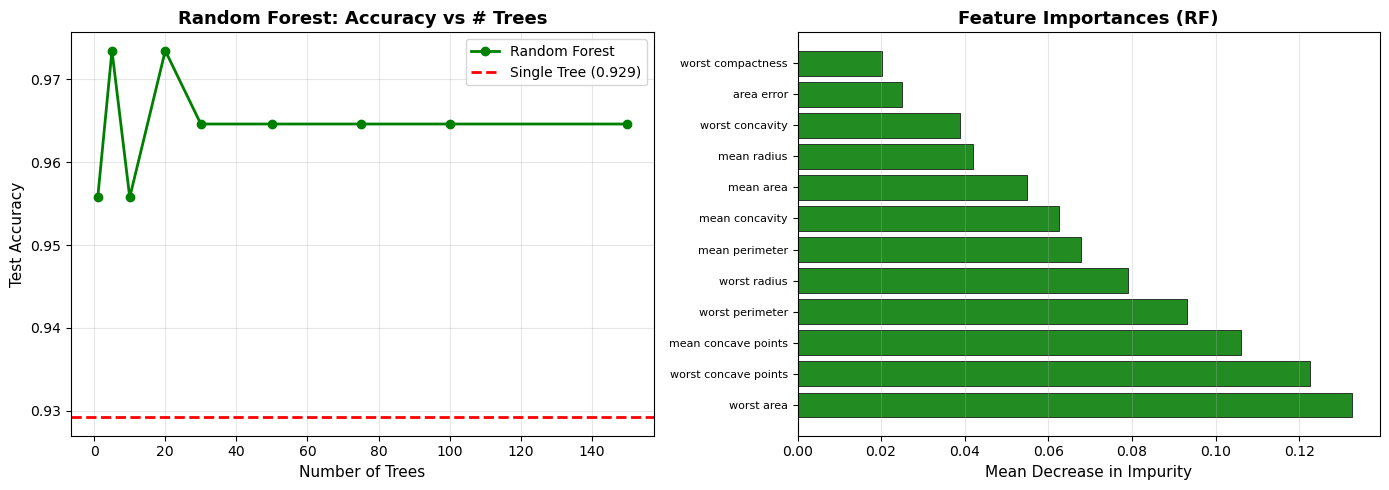

In [3]:
# Accuracy vs number of trees
n_trees_range = [1, 5, 10, 20, 30, 50, 75, 100, 150]
rf_accs, dt_accs_rep = [], []

for n in n_trees_range:
    rf_n = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42)
    rf_n.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf_n.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(n_trees_range, rf_accs, 'go-', linewidth=2, markersize=6, label='Random Forest')
ax.axhline(dt_acc, color='red', linestyle='--', linewidth=2, label=f'Single Tree ({dt_acc:.3f})')
ax.set_xlabel('Number of Trees', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Random Forest: Accuracy vs # Trees', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Feature importance
ax2 = axes[1]
# Compute feature importance from sklearn RF (our RF doesn't expose it yet)
importances = sk_rf.feature_importances_
top_idx = np.argsort(importances)[-12:][::-1]
ax2.barh(range(12), importances[top_idx], color='forestgreen', edgecolor='k', lw=0.5)
ax2.set_yticks(range(12))
ax2.set_yticklabels([feature_names[i][:22] for i in top_idx], fontsize=8)
ax2.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax2.set_title('Feature Importances (RF)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/random_forest_cancer.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Decision Boundary: Single Tree vs Random Forest (2D)

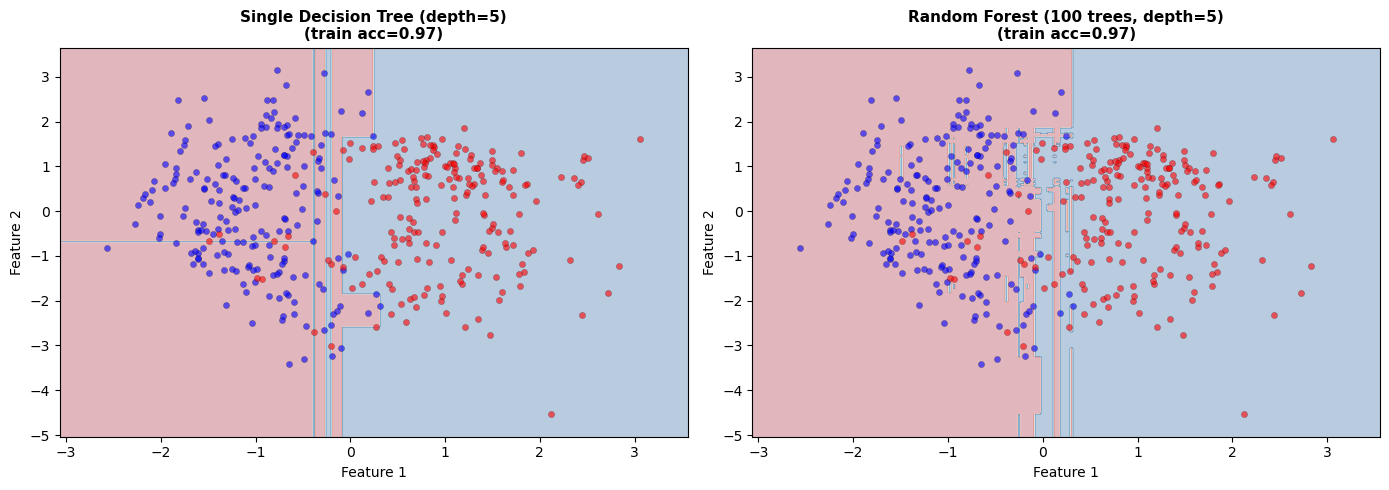

In [4]:
X_2d, y_2d = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    random_state=42, n_clusters_per_class=2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

models = [
    ('Single Decision Tree (depth=5)', DecisionTreeClassifier(max_depth=5)),
    ('Random Forest (100 trees, depth=5)', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
]

for ax, (title, model) in zip(axes, models):
    model.fit(X_2d, y_2d)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = accuracy_score(y_2d, model.predict(X_2d))
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], c='blue', s=20, alpha=0.6, edgecolors='k', lw=0.2)
    ax.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], c='red', s=20, alpha=0.6, edgecolors='k', lw=0.2)
    ax.set_title(f'{title}\n(train acc={acc:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=10)
    ax.set_ylabel('Feature 2', fontsize=10)

plt.tight_layout()
plt.savefig('figures/random_forest_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Iris — Multi-Class Classification

In [5]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

rf_iris = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_iris.fit(X_tr_i, y_tr_i)
print("Iris — Random Forest:")
print(classification_report(y_te_i, rf_iris.predict(X_te_i), target_names=list(iris.target_names)))

Iris — Random Forest:
     Class  Precision     Recall   F1-Score    Support
-------------------------------------------------------
    setosa     1.0000     1.0000     1.0000         10
versicolor     1.0000     1.0000     1.0000          9
 virginica     1.0000     1.0000     1.0000         11
-------------------------------------------------------
  accuracy                           1.0000         30


## Summary

| Property | Value |
|---|---|
| Type | Bagging ensemble of Decision Trees |
| Key ideas | Bootstrap sampling + random feature subsets |
| Aggregation | Majority vote (classification), Average (regression) |
| Advantage | Lower variance than single tree, robust, handles high dimensions |
| Disadvantage | Less interpretable, slower inference |

**Key Takeaways:**
- Random Forest improves over single trees by **reducing variance through averaging**
- Feature randomness at each split **decorrelates** the trees, making the ensemble more powerful
- Increasing the number of trees generally improves performance but with diminishing returns
- Random Forest naturally provides **feature importance** via mean impurity decrease